<a href="https://colab.research.google.com/github/Teodosiodg2002/Titanic-Kaggle-Dataset/blob/main/TitanicTeoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Celda 1: Carga de Datos y Comprobación de Nulos

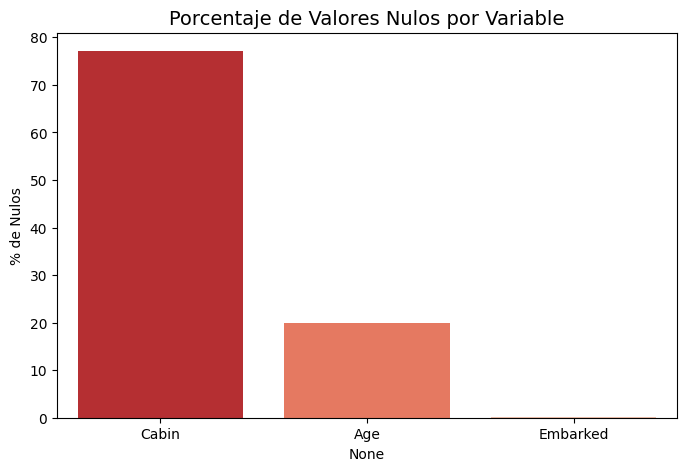

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==============================================================================
# 1. CARGA DE DATOS
# ==============================================================================
df_titanic = pd.read_csv('train.csv')

# ==============================================================================
# COMPROBACIÓN 1: ANÁLISIS DE NULOS
# ==============================================================================
# Calculamos el porcentaje de nulos
nulos = (df_titanic.isnull().sum() / len(df_titanic)) * 100
nulos = nulos[nulos > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=nulos.index, y=nulos.values, palette='Reds_r', hue=nulos.index, legend=False)
plt.title('Porcentaje de Valores Nulos por Variable', fontsize=14)
plt.ylabel('% de Nulos')
plt.savefig('1_comprobacion_nulos.png')
plt.show()

## Justificación:
'Cabin' tiene >77% de nulos, se descarta. 'Age' (20%) se recuperará con MICE. Y 'Embarked' (0,2%) se recuperará con la imputacion de la moda.

# Celda 2: Comprobación de Variables

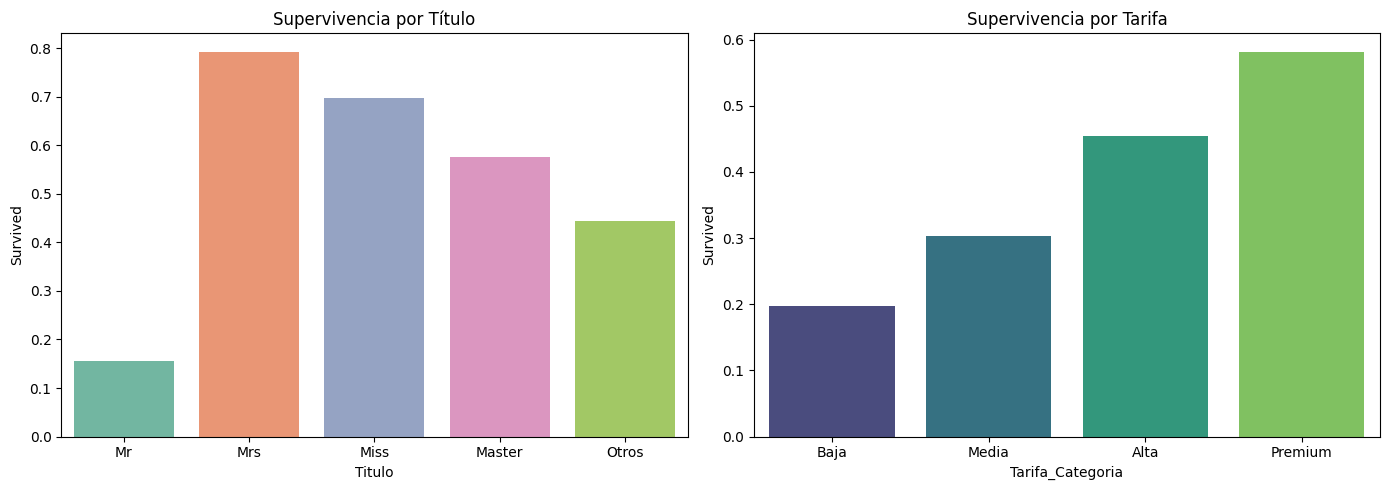

In [27]:
# ==============================================================================
# COMPROBACIÓN 2: ¿POR QUÉ CREAR NUEVAS VARIABLES? (EDA)
# ==============================================================================
df_eda = df_titanic.copy()

# Simulamos la creación del Título y Categoría de Tarifa para ver si afectan a la supervivencia
df_eda['Titulo'] = df_eda['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df_eda['Titulo'] = df_eda['Titulo'].apply(lambda x: x if x in ['Mr', 'Miss', 'Mrs', 'Master'] else 'Otros')
df_eda['Tarifa_Categoria'] = pd.qcut(df_eda['Fare'], q=4, labels=['Baja', 'Media', 'Alta', 'Premium'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Supervivencia por Título
sns.barplot(ax=axes[0], x='Titulo', y='Survived', data=df_eda, palette='Set2', hue='Titulo', legend=False, errorbar=None)
axes[0].set_title('Supervivencia por Título')

# Gráfico B: Supervivencia por Tarifa
sns.barplot(ax=axes[1], x='Tarifa_Categoria', y='Survived', data=df_eda, palette='viridis', hue='Tarifa_Categoria', legend=False, errorbar=None)
axes[1].set_title('Supervivencia por Tarifa')

plt.tight_layout()
plt.savefig('2_comprobacion_variables.png')
plt.show()


## Observación:
El título 'Master' (niños) sobrevive mucho más que 'Mr'. Las tarifas altas sobreviven más."

# Celda 3: Modelo Base (Sin Procesar)

In [28]:
df_base = df_titanic.copy()

# Imputación simple para que el modelo no falle
df_base['Age'] = df_base['Age'].fillna(df_base['Age'].median())
df_base['Embarked'] = df_base['Embarked'].fillna(df_base['Embarked'].mode()[0])

# ONE-HOT ENCODING (Mapeo estricto a 0 y 1 usando .astype(int))
X_base = pd.get_dummies(df_base[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']], drop_first=True).astype(int)
y_base = df_base['Survived']

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

arbol_base = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_base.fit(X_train_b, y_train_b)
acc_base = accuracy_score(y_val_b, arbol_base.predict(X_val_b))

# Celda 4: Preprocesamiento

In [29]:
df_limpio = df_titanic.copy()
df_limpio = df_limpio.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1)

# Imputación MICE para Age
df_mice = df_limpio[['Pclass', 'SibSp', 'Parch', 'Fare', 'Age']].copy()
df_limpio['Age'] = IterativeImputer(random_state=42).fit_transform(df_mice)[:, 4]
df_limpio['Embarked'] = df_limpio['Embarked'].fillna(df_limpio['Embarked'].mode()[0])

# Feature Engineering
df_limpio['Titulo'] = df_limpio['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
titulos_principales = ['Mr', 'Miss', 'Mrs', 'Master']
df_limpio['Titulo'] = df_limpio['Titulo'].apply(lambda x: x if x in titulos_principales else 'Otros')
df_limpio = df_limpio.drop(['Name'], axis=1)

df_limpio['Tamano_Familia'] = df_limpio['SibSp'] + df_limpio['Parch'] + 1
df_limpio['Tarifa_Categoria'] = pd.qcut(df_limpio['Fare'], q=4, labels=['Baja', 'Media', 'Alta', 'Premium'])
df_limpio['Pclass'] = df_limpio['Pclass'].astype(str)

# Celda 5: One-Hot Encoding Total y Modelo Optimizado

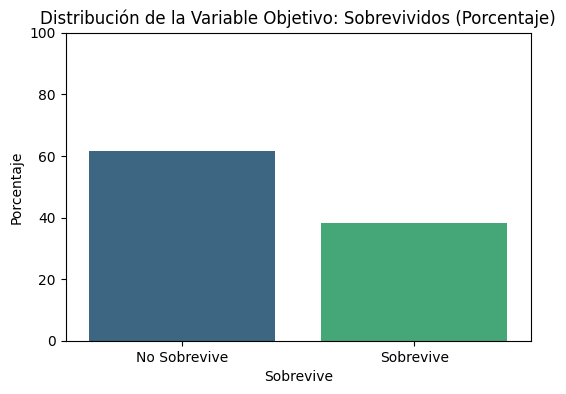

Vista de los datos listos para el modelo (Todo 0 y 1):
   Age  Tamano_Familia  Pclass_2  Pclass_3  Sex_male  Tarifa_Categoria_Media  \
0   22               2         0         1         1                       0   
1   38               2         0         0         0                       0   
2   26               1         0         1         0                       1   
3   35               2         0         0         0                       0   
4   35               1         0         1         1                       1   

   Tarifa_Categoria_Alta  Tarifa_Categoria_Premium  Titulo_Miss  Titulo_Mr  \
0                      0                         0            0          1   
1                      0                         1            0          0   
2                      0                         0            1          0   
3                      0                         1            0          0   
4                      0                         0            0          1

In [30]:
variables_finales = ['Survived', 'Pclass', 'Sex', 'Age', 'Tamano_Familia', 'Tarifa_Categoria', 'Titulo', 'Embarked']
df_final = df_limpio[variables_finales].copy()

# Visualización de la distribución de la variable objetivo 'Survived' en porcentajes
plt.figure(figsize=(6, 4))

survived_percentages = df_final['Survived'].value_counts(normalize=True) * 100
survived_percentages = survived_percentages.rename(index={0: 'No Sobrevive', 1: 'Sobrevive'})

sns.barplot(x=survived_percentages.index, y=survived_percentages.values, palette='viridis', hue=survived_percentages.index, legend=False)
plt.title('Distribución de la Variable Objetivo: Sobrevividos (Porcentaje)')
plt.xlabel('Sobrevive')
plt.ylabel('Porcentaje')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100
plt.savefig('5_distribucion_supervivencia_porcentaje.png')
plt.show()

X_opt = pd.get_dummies(df_final.drop('Survived', axis=1), drop_first=True).astype(int)
y_opt = df_final['Survived']

# Muestra cómo queda la tabla final (puro 0 y 1)
print("Vista de los datos listos para el modelo (Todo 0 y 1):")
print(X_opt.head())
print("\n")

X_train_o, X_val_o, y_train_o, y_val_o = train_test_split(X_opt, y_opt, test_size=0.2, random_state=42)

arbol_opt = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_opt.fit(X_train_o, y_train_o)
acc_opt = accuracy_score(y_val_o, arbol_opt.predict(X_val_o))

print("--- RESULTADOS CON ÁRBOL DE DECISIÓN ---")
print(f"Precisión Árbol Base:       {acc_base:.4f}")
print(f"Precisión Árbol Optimizado: {acc_opt:.4f}")
print(f"Mejora:                     {((acc_opt - acc_base) / acc_base) * 100:.2f}%\n")

# Celda 6: Visualización de los Árboles

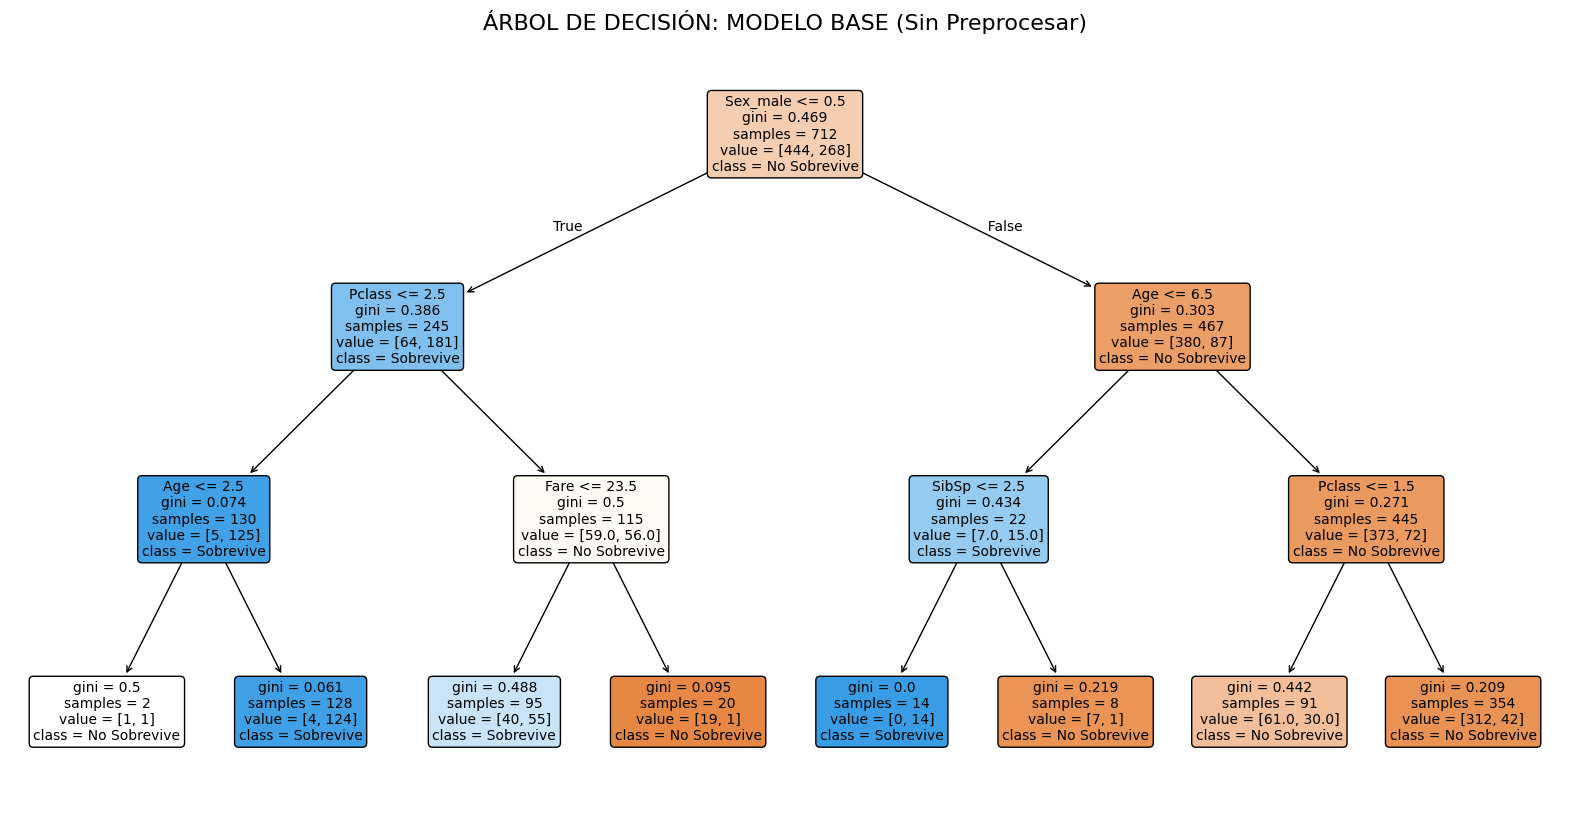

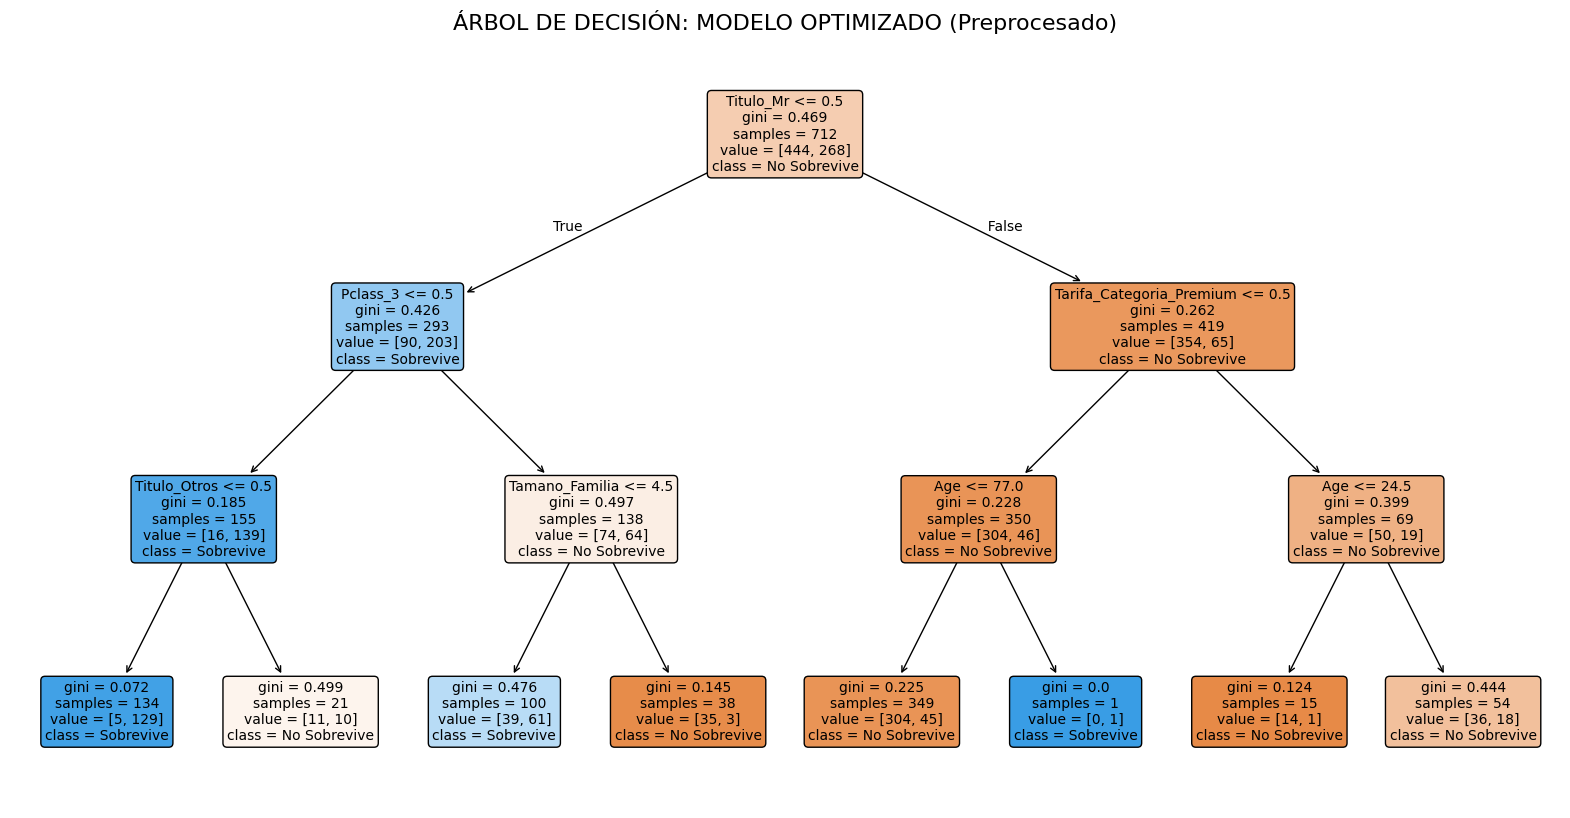

In [31]:
plt.figure(figsize=(20, 10))
plot_tree(arbol_base, feature_names=X_base.columns, class_names=['No Sobrevive', 'Sobrevive'], filled=True, rounded=True, fontsize=10)
plt.title("ÁRBOL DE DECISIÓN: MODELO BASE (Sin Preprocesar)", fontsize=16)
plt.savefig('3_arbol_base.png')
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(arbol_opt, feature_names=X_opt.columns, class_names=['No Sobrevive', 'Sobrevive'], filled=True, rounded=True, fontsize=10)
plt.title("ÁRBOL DE DECISIÓN: MODELO OPTIMIZADO (Preprocesado)", fontsize=16)
plt.savefig('4_arbol_optimizado.png')
plt.show()